In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import IPython
import dataclasses

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from meridian.analysis import analyzer
from meridian.analysis import visualizer
from meridian.model import model
from meridian.model import spec

from data_simulator import GeoMediaDataSimulator
from data_simulator import SimulationConfig
from model_utils import build_input_data
from model_utils import filter_param_summary

In [3]:
meridian_root = '/Users/mariappan.subramanian/Documents/repo/meridian/demo/synthetic/'

## Overall Setup

In [4]:
# Sample override dict for SimulationConfig.from_dict -- lets each notebook
# pass its own simulation settings without editing SimulationConfig itself.
# Unspecified fields fall back to the dataclass defaults. Tuple-typed fields
# (e.g. frequency_range, adstock_retention_range values) work as real tuples
# here since this is a Python dict, not JSON.
sample_config_overrides = {

    'target_audience_pop_frac': {'TV': 0.40, 'Display': 0.10, 'Social': 0.15},
    'current_reach_frac': {'TV': 0.3, 'Display': 0.5, 'Social': 0.9},  # TV: under-saturated, Display: close to saturated, Social: over-saturated
    'seasonal_amplitude': {'TV': 0.6, 'Display': 0.3, 'Social': 0.1},
    'geo_audience_heterogeneity_sd': 0.25,
    'frequency_range': (1.0, 6.0),
    'target_roi': {'TV': 3.5, 'Display': 2.0, 'Social': 1.5}
}

config = SimulationConfig.from_dict(sample_config_overrides)
simulator = GeoMediaDataSimulator(config)
config

SimulationConfig(
  n_imp_channels                = 3
  n_controls                    = 3
  n_times                       = 156
  seed_num                      = 1320
  channel_names                 = ['TV', 'Display', 'Social']
  control_names                 = ['sentiment_score', 'competitor_activity_score', 'seasonality_index']
  target_audience_pop_frac      = {'TV': 0.4, 'Display': 0.1, 'Social': 0.15}
  current_reach_frac            = {'TV': 0.3, 'Display': 0.5, 'Social': 0.9}
  frequency_range               = (1.0, 6.0)
  enable_ramp                   = False
  ramp_weeks                    = 10
  time_reach_noise_sd           = 0.03
  frequency_noise_sd            = 0.1
  geo_audience_heterogeneity_sd = 0.25
  demand_seasonal_peak_week     = 47
  seasonal_amplitude            = {'TV': 0.6, 'Display': 0.3, 'Social': 0.1}
  flight_burst_weeks            = {'TV': 8, 'Display': 2, 'Social': 2}
  flight_dark_weeks             = {'TV': 8, 'Display': 2, 'Social': 2}
  flight_floor    

I0000 00:00:1784653847.018908 2353371 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


percentage of sparsity of impression_gtm for each channel: ['0.00%', '0.00%', '0.00%']
TV: mean reach % = 0.203 (nominal target 0.3 -- seasonality /flighting/trend shift the realized average), mean frequency = 3.51 (target range (1.0, 6.0))
Display: mean reach % = 0.400 (nominal target 0.5 -- seasonality /flighting/trend shift the realized average), mean frequency = 3.51 (target range (1.0, 6.0))
Social: mean reach % = 0.753 (nominal target 0.9 -- seasonality /flighting/trend shift the realized average), mean frequency = 3.49 (target range (1.0, 6.0))


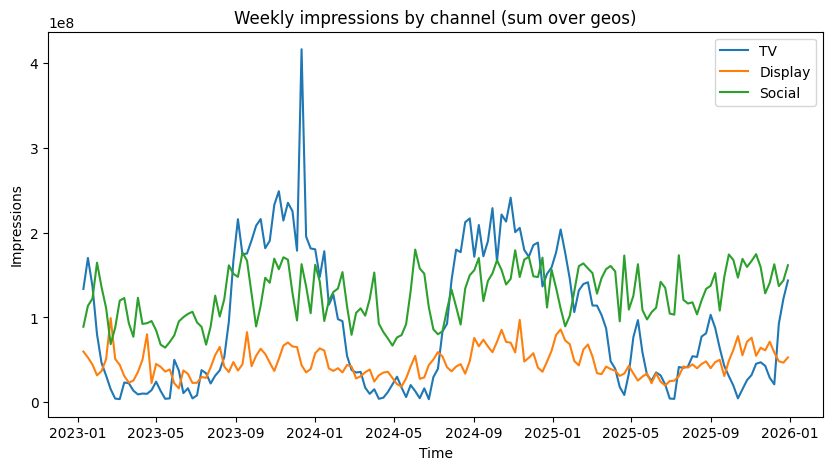

In [5]:
p_g = simulator.simulate_population()  # population
transformed_control_gtc = simulator.simulate_controls()  # simulate controls
impression_gtm = simulator.simulate_media()  # simulate media impressions
cost_gtm = simulator.simulate_cost_and_unit_value()  # simulate cost and unit value
mu_t = simulator.simulate_intercepts()  # simulate intercepts
simulator.plot_media_time_series()  # plot media time series
plt.show()

In [6]:
beta_gm = simulator.simulate_coefficients()  # simulate coefficients
ec_m = simulator.simulate_adstock_hill_params()  # simulate adstock hill params
media_transformed = simulator.transform_media()  # transform media
beta_gm = simulator.calibrate_channel_effects()

print(f"simulated alpha_m: {simulator.alpha_m.numpy()}")
print(f"simulated ec_m: {simulator.ec_m.numpy()}")
print(f"simulated slope_m: {simulator.slope_m.numpy()}")

ec_m = [4.1838937 1.4535712 0.7145933]
simulated alpha_m: [0.74826247 0.2828253  0.23166814]
simulated ec_m: [4.1838937 1.4535712 0.7145933]
simulated slope_m: [1. 1. 1.]


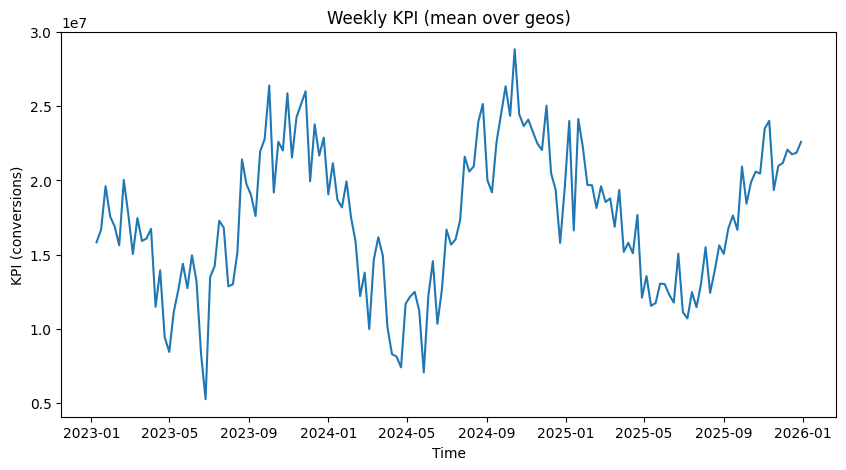

In [7]:
kpi_gt = simulator.generate_kpi_and_revenue()  # finally generate kpi and revenue
simulator.plot_kpi_time_series()
plt.show()

In [8]:
geo_data_df = simulator.to_dataframe()
geo_data_df.head()

,geo,time,Display_impression,Social_impression,TV_impression,competitor_activity_score_control,seasonality_index_control,sentiment_score_control,Display_spend,Social_spend,TV_spend,Display_reach,Social_reach,TV_reach,Display_frequency,Social_frequency,TV_frequency,conversions,revenue_per_conversion,population
0,Alabama,2023-01-09,1379805.0,2411084.0,1576550.0,0.537944,0.737785,1.351428,2776.377930,11603.292969,15953.751953,234875.281250,475505.8125,424247.81250,5.874630,5.070566,3.716106,15276152.0,0.035049,5193088.0
1,Alabama,2023-01-16,423112.0,1673670.0,2887964.0,0.845643,0.593424,0.657998,851.365784,8054.503418,29224.486328,237291.937500,451853.2500,484524.09375,1.783086,3.704011,5.960414,17681578.0,0.034529,5193088.0
2,Alabama,2023-01-23,186967.0,2855707.0,1520083.0,-0.233666,0.440453,0.900505,376.206085,13743.033203,15382.339844,166279.640625,531139.7500,374432.59375,1.124412,5.376565,4.059697,17370652.0,0.034954,5193088.0
3,Alabama,2023-01-30,210407.0,1542932.0,1397583.0,-0.754862,0.281102,-2.214974,423.370972,7425.329590,14142.711914,121585.039062,609791.4375,284999.93750,1.730536,2.530261,4.903801,7635858.5,0.034622,5193088.0
4,Alabama,2023-02-06,541217.0,3021827.0,343366.0,-0.093950,0.117695,-1.280288,1089.011108,14542.482422,3474.660400,152782.031250,530369.1875,171891.59375,3.542411,5.697592,1.997571,10295822.0,0.034928,5193088.0


In [9]:
ground_truth_roi = simulator.compute_ground_truth()
ground_truth_roi['roi_m']

ground-truth ROI for every channel = [3.5000005 1.9999996 1.4999998]
ground-truth total incremental ROI = 2.67

Total revenue = 138453.48M
Total ROI = 540.0538330078125


array([3.5000005, 1.9999996, 1.4999998], dtype=float32)

1. Default Prior Model

In [10]:
data = build_input_data(
    geo_data_df, config.channel_names, simulator.control_col_names
)

model_spec = spec.ModelSpec(
    media_prior_type='roi', media_effects_dist='log_normal', knots=8
)

mmm = model.Meridian(input_data=data, model_spec=model_spec)
mmm.sample_prior(500)
mmm.sample_posterior(n_chains=2, n_adapt=2000, n_burnin=500, n_keep=1000, seed=1)

# 1. model diagnostics
model_diagnostics = visualizer.ModelDiagnostics(mmm)
model_diagnostics_df = model_diagnostics.predictive_accuracy_table().copy()

# 2. model parameters summary
model_summary_df = az.summary(
    mmm.inference_data,
    stat_funcs={'median': lambda x: np.median(x, axis=0)},
    extend=True,
).reset_index()

meffects_period_full = visualizer.MediaSummary(mmm).summary_table()


display(model_diagnostics_df)
display(filter_param_summary(model_summary_df, 'ec_m'))
display(filter_param_summary(model_summary_df, 'alpha_m'))
display(filter_param_summary(model_summary_df, 'roi_m'))
display(meffects_period_full)

2026-07-21 12:11:20.004175: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encount

,metric,geo_granularity,value
0,R_Squared,geo,0.982441
1,R_Squared,national,0.855438
2,MAPE,geo,0.124851
3,MAPE,national,0.096602
4,wMAPE,geo,0.087116
5,wMAPE,national,0.082997


,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
159,ec_m[TV],0.529,0.091,0.363,0.694,0.004,0.003,604.0,836.0,1.01,0.524
160,ec_m[Display],1.213,0.626,0.104,2.228,0.015,0.011,1468.0,855.0,1.00,1.175
161,ec_m[Social],0.119,0.020,0.100,0.155,0.001,0.000,1380.0,1357.0,1.00,0.112


,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
0,alpha_m[TV],0.989,0.009,0.972,1.0,0.000,0.000,1957.0,959.0,1.0,0.992
1,alpha_m[Display],0.817,0.207,0.365,1.0,0.005,0.003,1698.0,1220.0,1.0,0.893
2,alpha_m[Social],0.980,0.019,0.945,1.0,0.000,0.000,1896.0,861.0,1.0,0.985


,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
485,roi_m[TV],7.740,0.694,6.451,8.984,0.024,0.017,822.0,1245.0,1.0,7.693
486,roi_m[Display],4.048,4.344,0.061,12.456,0.112,0.079,1642.0,1699.0,1.0,2.269
487,roi_m[Social],11.811,2.200,7.833,15.973,0.066,0.047,1104.0,1316.0,1.0,11.846


,channel,distribution,impressions,% impressions,spend,% spend,cpm,incremental outcome,% contribution,roi,effectiveness,mroi,cpik
0,TV,prior,"14,468,784,128",35%,"$146,415,456",57%,$10,"$283,441,856 ($44,171,580, $908,464,384)","5.0% (0.8%, 15.9%)","1.9 (0.3, 6.2)","0.02 (0.00, 0.06)","0.7 (0.1, 2.0)","$0.0 ($0.0, $0.1)"
1,TV,posterior,"14,468,784,128",35%,"$146,415,456",57%,$10,"$1,133,260,288 ($981,512,128, $1,309,604,864)","23.4% (20.2%, 27.0%)","7.7 (6.7, 8.9)","0.08 (0.07, 0.09)","2.2 (2.0, 2.4)","$0.0 ($0.0, $0.0)"
2,Display,prior,"7,306,185,728",18%,"$14,701,145",6%,$2,"$28,426,164 ($3,837,118, $75,748,832)","0.5% (0.1%, 1.3%)","1.9 (0.3, 5.2)","0.00 (0.00, 0.01)","0.8 (0.1, 2.5)","$0.0 ($0.0, $0.1)"
3,Display,posterior,"7,306,185,728",18%,"$14,701,145",6%,$2,"$59,510,508 ($4,466,690, $196,077,120)","1.2% (0.1%, 4.0%)","4.0 (0.3, 13.3)","0.01 (0.00, 0.03)","2.0 (0.1, 6.8)","$0.0 ($0.0, $0.1)"
4,Social,prior,"19,793,035,264",48%,"$95,253,144",37%,$5,"$175,864,992 ($24,507,160, $526,833,504)","3.1% (0.4%, 9.2%)","1.8 (0.3, 5.5)","0.01 (0.00, 0.03)","0.8 (0.1, 2.7)","$0.0 ($0.0, $0.1)"
5,Social,posterior,"19,793,035,264",48%,"$95,253,144",37%,$5,"$1,125,042,304 ($769,047,680, $1,451,232,512)","23.2% (15.9%, 29.9%)","11.8 (8.1, 15.2)","0.06 (0.04, 0.07)","1.3 (0.9, 1.6)","$0.0 ($0.0, $0.0)"
6,All Channels,prior,"41,568,006,144",100%,"$256,369,760",100%,$6,"$487,732,960 ($130,335,112, $1,116,204,928)","8.5% (2.3%, 19.5%)","1.9 (0.5, 4.4)","nan (nan, nan)","nan (nan, nan)","$0.0 ($0.0, $0.1)"
7,All Channels,posterior,"41,568,006,144",100%,"$256,369,760",100%,$6,"$2,317,812,224 ($1,998,757,376, $2,634,414,080)","47.8% (41.2%, 54.3%)","9.0 (7.8, 10.3)","nan (nan, nan)","nan (nan, nan)","$0.0 ($0.0, $0.0)"


Informed Priors

In [24]:
# -- half saturation prior
import tensorflow_probability as tfp
from meridian import constants
from meridian.model import prior_distribution

# half_saturation_multiplier_prior = {
#     'TV': [2.5, 0.1],
#     'Display': [1.5, 0.1],
#     'Social': [0.7, 0.1]
# }

half_saturation_multiplier_prior = {
  chnl: [round(val.item(), 2), 0.1] for chnl, val in zip(config.channel_names, list(simulator.ec_m.numpy()))
  }


ordered_chnl_names = config.channel_names  # ['TV', 'Display', 'Social']
ec50_mu_array = [half_saturation_multiplier_prior[col][0] for col in ordered_chnl_names]
ec50_deviation_pct_array = [half_saturation_multiplier_prior[col][1] for col in ordered_chnl_names]
ec50_log_loc_array = np.log(ec50_mu_array)
ec50_scale_array = np.array(ec50_deviation_pct_array)  # kept as-is, not scaled by mu

ec_m = tfp.distributions.LogNormal(
    loc=[float(x) for x in ec50_log_loc_array],
    scale=[float(x) for x in ec50_scale_array],
    name=constants.EC_M)


prior = prior_distribution.PriorDistribution(ec_m=ec_m)
model_spec2 = spec.ModelSpec(prior=prior, media_prior_type='roi', media_effects_dist='log_normal', knots=8)
mmm2 = model.Meridian(input_data=data, model_spec=model_spec2)
mmm2.sample_prior(500)
mmm2.sample_posterior(n_chains=2, n_adapt=2000, n_burnin=500, n_keep=1000, seed=1)

# 1. model diagnostics
model_diagnostics = visualizer.ModelDiagnostics(mmm2)
model_diagnostics_df = model_diagnostics.predictive_accuracy_table().copy()

# 2. model parameters summary
model_summary_df = az.summary(
    mmm2.inference_data,
    stat_funcs={'median': lambda x: np.median(x, axis=0)},
    extend=True,
).reset_index()

meffects_period_full = visualizer.MediaSummary(mmm2).summary_table()


display(model_diagnostics_df)
display(filter_param_summary(model_summary_df, 'ec_m'))
display(filter_param_summary(model_summary_df, 'alpha_m'))
display(filter_param_summary(model_summary_df, 'roi_m'))
display(meffects_period_full)

2026-07-21 12:49:11.700648: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encount

,metric,geo_granularity,value
0,R_Squared,geo,0.982079
1,R_Squared,national,0.851090
2,MAPE,geo,0.126689
3,MAPE,national,0.098489
4,wMAPE,geo,0.088379
5,wMAPE,national,0.084923


,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
159,ec_m[TV],2.287,0.198,1.899,2.635,0.005,0.004,1642.0,1641.0,1.0,2.281
160,ec_m[Display],1.453,0.147,1.171,1.709,0.003,0.002,1760.0,1334.0,1.0,1.444
161,ec_m[Social],0.647,0.071,0.516,0.778,0.002,0.002,914.0,1151.0,1.0,0.643


,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
0,alpha_m[TV],0.938,0.021,0.898,0.977,0.001,0.001,688.0,589.0,1.0,0.938
1,alpha_m[Display],0.903,0.122,0.714,1.000,0.006,0.004,629.0,713.0,1.0,0.939
2,alpha_m[Social],0.954,0.083,0.891,1.000,0.007,0.005,678.0,583.0,1.0,0.970


,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
485,roi_m[TV],4.653,0.244,4.184,5.088,0.006,0.005,1418.0,1195.0,1.00,4.655
486,roi_m[Display],9.569,6.048,0.150,18.895,0.340,0.241,333.0,766.0,1.01,9.517
487,roi_m[Social],4.405,1.212,2.274,6.652,0.064,0.045,372.0,397.0,1.00,4.426


,channel,distribution,impressions,% impressions,spend,% spend,cpm,incremental outcome,% contribution,roi,effectiveness,mroi,cpik
0,TV,prior,"14,468,784,128",35%,"$146,415,456",57%,$10,"$267,377,712 ($39,813,100, $783,836,480)","5.0% (0.8%, 14.8%)","1.8 (0.3, 5.4)","0.02 (0.00, 0.05)","1.2 (0.2, 3.5)","$0.0 ($0.0, $0.1)"
1,TV,posterior,"14,468,784,128",35%,"$146,415,456",57%,$10,"$681,290,944 ($624,297,984, $739,806,144)","14.1% (12.9%, 15.3%)","4.7 (4.3, 5.1)","0.05 (0.04, 0.05)","2.5 (2.3, 2.7)","$0.0 ($0.0, $0.0)"
2,Display,prior,"7,306,185,728",18%,"$14,701,145",6%,$2,"$26,201,538 ($4,657,776, $78,346,936)","0.5% (0.1%, 1.5%)","1.8 (0.3, 5.3)","0.00 (0.00, 0.01)","1.0 (0.2, 2.9)","$0.0 ($0.0, $0.1)"
3,Display,posterior,"7,306,185,728",18%,"$14,701,145",6%,$2,"$140,673,744 ($10,201,898, $283,081,504)","2.9% (0.2%, 5.8%)","9.6 (0.7, 19.3)","0.02 (0.00, 0.04)","5.3 (0.4, 10.6)","$0.0 ($0.0, $0.1)"
4,Social,prior,"19,793,035,264",48%,"$95,253,144",37%,$5,"$157,062,960 ($27,503,858, $423,863,200)","3.0% (0.5%, 8.0%)","1.6 (0.3, 4.4)","0.01 (0.00, 0.02)","0.7 (0.1, 1.7)","$0.0 ($0.0, $0.1)"
5,Social,posterior,"19,793,035,264",48%,"$95,253,144",37%,$5,"$419,575,040 ($237,214,784, $603,028,800)","8.7% (4.9%, 12.4%)","4.4 (2.5, 6.3)","0.02 (0.01, 0.03)","1.7 (1.0, 2.3)","$0.0 ($0.0, $0.0)"
6,All Channels,prior,"41,568,006,144",100%,"$256,369,760",100%,$6,"$450,642,240 ($129,065,472, $1,012,782,656)","8.5% (2.4%, 19.1%)","1.8 (0.5, 4.0)","nan (nan, nan)","nan (nan, nan)","$0.0 ($0.0, $0.1)"
7,All Channels,posterior,"41,568,006,144",100%,"$256,369,760",100%,$6,"$1,241,541,120 ($1,094,210,944, $1,394,268,416)","25.6% (22.6%, 28.8%)","4.8 (4.3, 5.4)","nan (nan, nan)","nan (nan, nan)","$0.0 ($0.0, $0.0)"


Informed Prior ==> Half Saturation and Adstock

In [ ]:
# -- adstock prior
adstock_prior = {
    'TV': [0.6, 0.8],
    'Display': [0, 0.4],
    'Social': [0.1, 0.4]
}

adstock_lower_bounds = [adstock_prior[col][0] for col in ordered_chnl_names]
adstock_upper_bounds = [adstock_prior[col][1] for col in ordered_chnl_names]
alpha_m=tfp.distributions.Uniform([float(x) for x in adstock_lower_bounds], [float(x) for x in adstock_upper_bounds], name=constants.ALPHA_M)


prior = prior_distribution.PriorDistribution(ec_m=ec_m, alpha_m=alpha_m)
model_spec3 = spec.ModelSpec(prior=prior, media_prior_type='roi', media_effects_dist='log_normal', knots=8)
mmm3 = model.Meridian(input_data=data, model_spec=model_spec3)
mmm3.sample_prior(500)
mmm3.sample_posterior(n_chains=2, n_adapt=2000, n_burnin=500, n_keep=1000, seed=1)


# 1. model diagnostics
model_diagnostics = visualizer.ModelDiagnostics(mmm3)
model_diagnostics_df = model_diagnostics.predictive_accuracy_table().copy()

# 2. model parameters summary
model_summary_df = az.summary(
    mmm3.inference_data,
    stat_funcs={'median': lambda x: np.median(x, axis=0)},
    extend=True,
).reset_index()

meffects_period_full = visualizer.MediaSummary(mmm3).summary_table()


display(model_diagnostics_df)
display(filter_param_summary(model_summary_df, 'ec_m'))
display(filter_param_summary(model_summary_df, 'alpha_m'))
display(filter_param_summary(model_summary_df, 'roi_m'))
display(meffects_period_full)

2026-07-21 12:59:10.307040: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


Informed Priors - Adstock ONLY

In [ ]:
# -- adstock prior
adstock_prior = {
    'TV': [0.6, 0.8],
    'Display': [0, 0.4],
    'Social': [0.1, 0.4]
}

adstock_lower_bounds = [adstock_prior[col][0] for col in ordered_chnl_names]
adstock_upper_bounds = [adstock_prior[col][1] for col in ordered_chnl_names]
alpha_m=tfp.distributions.Uniform([float(x) for x in adstock_lower_bounds], [float(x) for x in adstock_upper_bounds], name=constants.ALPHA_M)

prior = prior_distribution.PriorDistribution(alpha_m=alpha_m)
model_spec4 = spec.ModelSpec(prior=prior, media_prior_type='roi', media_effects_dist='log_normal', knots=8)
mmm4 = model.Meridian(input_data=data, model_spec=model_spec4)
mmm4.sample_prior(500)
mmm4.sample_posterior(n_chains=2, n_adapt=2000, n_burnin=500, n_keep=1000, seed=1)


# 1. model diagnostics
model_diagnostics = visualizer.ModelDiagnostics(mmm4)
model_diagnostics_df = model_diagnostics.predictive_accuracy_table().copy()

# 2. model parameters summary
model_summary_df = az.summary(
    mmm4.inference_data,
    stat_funcs={'median': lambda x: np.median(x, axis=0)},
    extend=True,
).reset_index()

meffects_period_full = visualizer.MediaSummary(mmm4).summary_table()


display(model_diagnostics_df)
display(filter_param_summary(model_summary_df, 'ec_m'))
display(filter_param_summary(model_summary_df, 'alpha_m'))
display(filter_param_summary(model_summary_df, 'roi_m'))
display(meffects_period_full)

2026-07-20 20:52:51.203476: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
